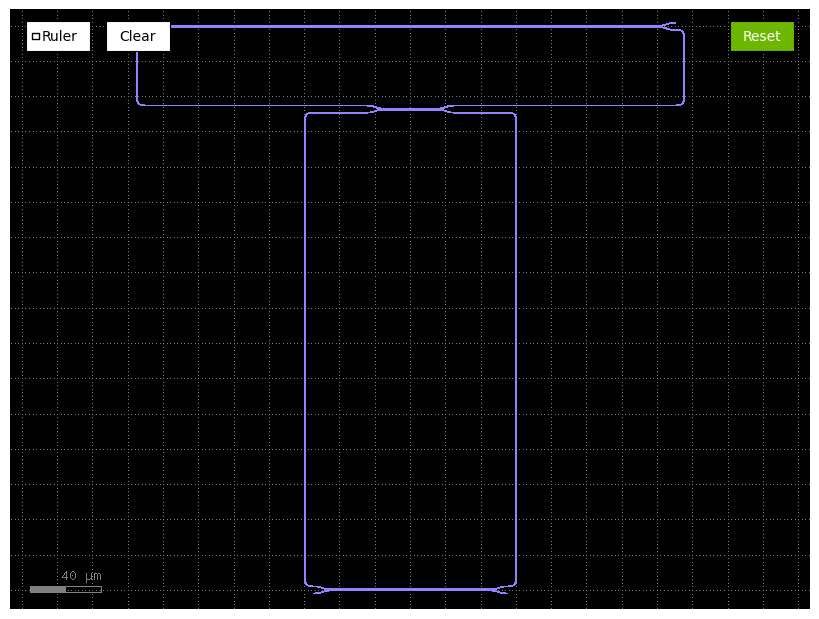

In [6]:
import gdsfactory as gf
import numpy as np
import cspdk.si220.cband
from typing import List
from axiomatic.pic_helpers import plot_circuit

cspdk.si220.cband.activate_pdk()

pdk = gf.get_active_pdk()


def crow_filter(
    coupling_lengths: List[float],
    target_fsrs: List[float],
    coupling_gap: float,
    center_wvl: float,
    bend_radius: float = 5.0,
) -> gf.Component:
    """
    Generates a CROW filter with N resonators.
    
    Args:
        coupling_lengths: List of coupling region lengths [um] for each coupler.
        target_fsrs: List of FSRs [THz] for each ring.
        coupling_gap: Coupling gap [um].
        center_wvl: Center wavelength [um].

    Returns:
        Component with the CROW filter layout.
    """

    assert len(coupling_lengths) == len(target_fsrs), \
        "Each ring must have a coupling length and target FSR."
    n_eff = 2.38
    n_g = 4.3

    # Create main component
    c = gf.Component()
    coupler = lambda L: pdk.get_component("coupler", length=L, gap=coupling_gap)

    # Create couplers and compute each ring's round-trip length
    dcs = []
    ring_lengths_target = []
    for length, fsr in zip(coupling_lengths, target_fsrs):
        cavity_length_target_fsr = center_wvl**2 / (n_g * fsr * 1e-3)
        m = round(n_eff * cavity_length_target_fsr / center_wvl)
        ring_length_target = m * center_wvl / n_eff
        ring_lengths_target.append(ring_length_target)

        # Instantiate coupler
        dc = c << coupler(length)
        dcs.append(dc)

    # Calculate total length of bends and couplers for each ring
    bend_length_total = np.pi * bend_radius  # 180 deg bend
    dc_lengths = [dc.cell.info["length"] for dc in dcs]

    # Compute vertical straight sections for each ring
    y_dists = []
    for i, ring_length_target in enumerate(ring_lengths_target):
        y_dist = (ring_length_target - (2 * bend_length_total + dc_lengths[i])) / 2
        y_dists.append(y_dist)

    # Place couplers vertically
    dy = abs(dcs[-1].ports["o2"].center[1] - dcs[-1].ports["o1"].center[1])
    y_offset = 0
    for i, (dc, y_dist) in enumerate(zip(dcs, y_dists)):
        bbox = dc.bbox()
        center_x = (bbox.left + bbox.right) / 2
        dc.move((-center_x, y_offset))
        y_offset += y_dist + dy + 2 * bend_radius

    # Connect top-to-bottom of neighboring couplers
    for i in range(len(dcs) - 1):
        upper_right_conn = dcs[i].ports["o3"]
        lower_right_conn = dcs[i+1].ports["o4"]

        gf.routing.route_single(
            component=c,
            port1=upper_right_conn,
            port2=lower_right_conn,
            bend="bend_euler",
            cross_section="strip"
        )

        upper_left_conn = dcs[i+1].ports["o1"]
        lower_left_conn = dcs[i].ports["o2"]

        gf.routing.route_single(
            component=c,
            port1=upper_left_conn,
            port2=lower_left_conn,
            bend="bend_euler",
            cross_section="strip"
        )

    return c


# Example usage and plot
if __name__ == "__main__":
    c = crow_filter(
        coupling_lengths=[90, 30, 280],  # Example: three rings
        target_fsrs=[1, 5.2, 8],       # Example: different FSRs [THz]
        coupling_gap=0.2,
        center_wvl=1.55,
        bend_radius=5
    )
    plot_circuit(c)
